# Target Definition and Exploratory Analysis

This notebook defines and evaluates the binary classification target for the hospital excess readmission project. The goal is to determine whether the excess readmission ratio threshold is reasonable and whether the target classes are balanced enough for modeling.

## Excess Readmission Ratio Distribution

Before creating a binary target, I inspect the continuous excess readmission ratio distribution. This helps show whether values are tightly clustered around the threshold or clearly separated into groups.

## Target Threshold Evaluation

The proposed target classifies records as high excess readmission when ERR is greater than 1.0. Values less than or equal to 1.0 are treated as the non-excess class. Exact ERR values equal to 1.0 are checked before finalizing this threshold.

## Class Balance Check

Class balance is evaluated by counting how many records fall above and at or below the ERR threshold. This determines whether the target is heavily imbalanced or suitable for baseline classification modeling.

## Distribution Interpretation

The ERR distribution is tightly centered around 1.0, meaning many records are close to the classification boundary. This makes the classification problem more realistic but also more difficult, because small differences around the threshold can place similar records into opposite classes.

In [32]:
#Import pandas for loading in data
import pandas as pd

#Load processed dataset containing valid ERR records
df_valid_err = pd.read_parquet("../data/processed/valid_err.parquet")

#Confirm dataset dimensions after loading
df_valid_err.shape

df_valid_err.head()

,facility_name,facility_id,state,measure_name,number_of_discharges,footnote,excess_readmission_ratio,predicted_readmission_rate,expected_readmission_rate,number_of_readmissions,start_date,end_date
0,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-CABG-HRRP,137.0,NaN,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-AMI-HRRP,273.0,NaN,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024
3,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-COPD-HRRP,122.0,NaN,0.9823,16.6384,16.9389,19,07/01/2021,06/30/2024
4,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-PN-HRRP,507.0,NaN,0.9871,15.7529,15.9591,79,07/01/2021,06/30/2024


In [33]:
# Check how many measure records each hospital contains
# after filtering valid ERR rows
df_valid_err.groupby('facility_id')['measure_name'].count()

# Inspect unique values inside number_of_readmissions
# to identify suppressed/non-numeric reporting values
df_valid_err['number_of_readmissions'].value_counts()

# Inspect readmission count distributions by measure category
df_valid_err.groupby('measure_name')['number_of_readmissions'].value_counts()


#Inspect how target classes are distributed across measure categories
df_valid_err.groupby(df_valid_err['excess_readmission_ratio'] > 1)['measure_name'].value_counts()

excess_readmission_ratio  measure_name          
False                     READM-30-PN-HRRP          1444
                          READM-30-HF-HRRP          1339
                          READM-30-COPD-HRRP        1226
                          READM-30-AMI-HRRP          874
                          READM-30-HIP-KNEE-HRRP     754
                          READM-30-CABG-HRRP         440
True                      READM-30-HF-HRRP          1282
                          READM-30-PN-HRRP          1271
                          READM-30-COPD-HRRP        1097
                          READM-30-AMI-HRRP          862
                          READM-30-HIP-KNEE-HRRP     693
                          READM-30-CABG-HRRP         438
Name: count, dtype: int64

In [34]:
# Numerical summary statistics for ERR distribution
df_valid_err['excess_readmission_ratio'].describe()

count    11720.000000
mean         1.001777
std          0.082050
min          0.469800
25%          0.958200
50%          0.997300
75%          1.042300
max          1.629700
Name: excess_readmission_ratio, dtype: float64

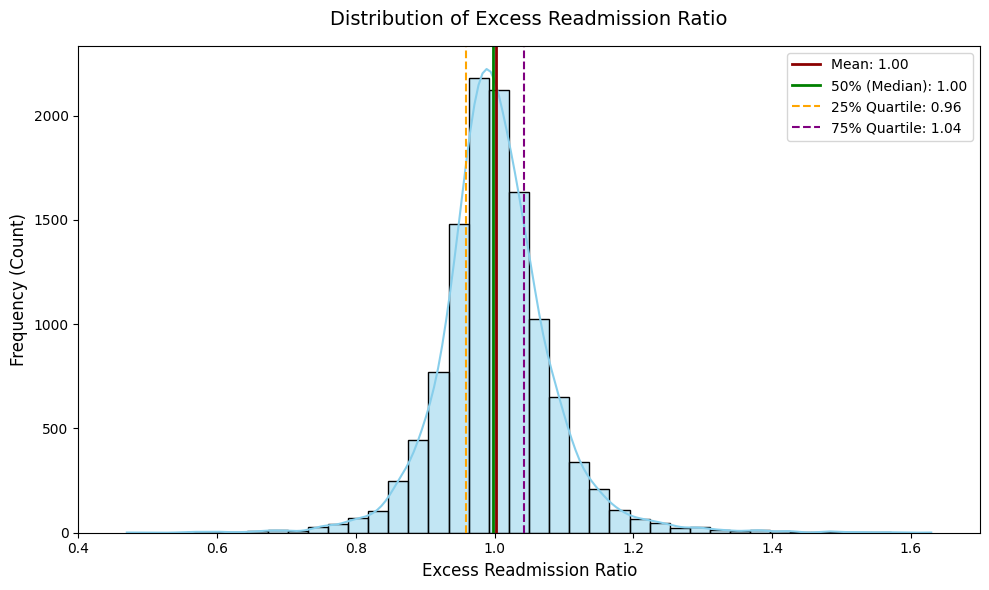

In [35]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure canvas
plt.figure(figsize=(10, 6))

# Plot histogram + KDE for ERR distribution
sns.histplot(df_valid_err['excess_readmission_ratio'], bins=40, kde=True, color='skyblue', edgecolor='black')

# Add statistical reference lines from describe() output
plt.axvline(1.001777, color='darkred', linestyle='-', linewidth=2, label='Mean: 1.00')
plt.axvline(0.997300, color='green', linestyle='-', linewidth=2, label='50% (Median): 1.00')
plt.axvline(0.958200, color='orange', linestyle='--', linewidth=1.5, label='25% Quartile: 0.96')
plt.axvline(1.042300, color='purple', linestyle='--', linewidth=1.5, label='75% Quartile: 1.04')

# Final chart formatting
plt.title('Distribution of Excess Readmission Ratio', fontsize=14, pad=15)
plt.xlabel('Excess Readmission Ratio', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)

# Set x-axis range based on observed ERR spread
plt.xlim(0.4, 1.7) 

# Show legend
plt.legend(loc='upper right')

# Prevent overlapping elements
plt.tight_layout()

# Display plot
plt.show()


## Feature Selection and Leakage Review

Before modeling, each column was reviewed for analytical usefulness and leakage risk. The final conservative feature set includes `state`, `measure_name`, and `number_of_discharges`.

`state` is included as a geographic/contextual feature. `measure_name` is included because different HRRP measure categories represent different clinical and operational reporting groups. `number_of_discharges` is included as an operational volume feature.

The leakage-related columns `excess_readmission_ratio`, `predicted_readmission_rate`, and `expected_readmission_rate` are excluded because the target is defined from ERR, and the rate columns are directly related to the ERR calculation. `facility_id` and `facility_name` are excluded because they are identifiers. `start_date` and `end_date` are excluded because they do not add useful variation. `footnote` and `number_of_readmissions` are excluded under a conservative modeling approach.

## Remaining Missing Values in Number of Discharges

After filtering to valid ERR rows, `number_of_discharges` still contained missing values. Because this column is retained as an operational volume feature, those missing values had to be resolved before modeling.

The missing discharge values were reviewed by `measure_name` to check whether they were concentrated in one measure category. The missingness appeared spread across measure groups rather than isolated to a single measure.

## Dropping Rows With Missing Number of Discharges

Rows with missing `number_of_discharges` were removed before modeling. This was chosen instead of imputation because a large share of the column was missing, and imputing could introduce artificial volume patterns.

After dropping these rows, the ERR distribution remained broadly similar, with the mean, median, quartiles, and spread still centered near 1.0. This suggests that removing these rows did not fundamentally distort the target distribution.

In [36]:
#Formally create the target column 
df_valid_err['high_excess_readmission'] = (
    df_valid_err['excess_readmission_ratio'] > 1
).astype(int)

#Inspect remaining null values in number_of_discharges column
df_valid_err['number_of_discharges'].isna().sum()

#Inspect whether removing null values impacts the distribution of measure_name data
df_valid_err[df_valid_err['number_of_discharges'].isna()]['measure_name'].value_counts()

#After validating that removing null values still kept the data consistent,
#drop the null values for modeling
df_valid_err = df_valid_err.dropna(subset = ['number_of_discharges'])

#Check if there are any remaining null values
df_valid_err.isna().sum()

#Reconfirm the distribution of data after removing null values
df_valid_err['excess_readmission_ratio'].describe()

#Confirm data types before creating final modeling dataframe
df_valid_err.dtypes

#Take the columns to be included and create a modeling ready dataframe
df_model_ready = df_valid_err[['state', 'measure_name',
                'number_of_discharges', 'high_excess_readmission']]

#Export final modeling dataframe
df_model_ready.to_parquet('../data/processed/df_model_ready.parquet')

## Final Modeling Dataset

The final modeling dataset contains only the selected features and target variable:

- `state`
- `measure_name`
- `number_of_discharges`
- `high_excess_readmission`

The final data types were checked before export. `state` and `measure_name` are string/object fields, `number_of_discharges` is numeric (`float64`), and `high_excess_readmission` is binary integer (`int64`).

## Export Final Modeling Dataset

The final modeling-ready dataframe is exported as a Parquet file so it can be loaded cleanly in the modeling notebook. This keeps the cleaning, EDA, and modeling phases separated across notebooks.